In [3]:
import sys
!{sys.executable} -m pip install torchsummary

In [4]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [5]:
data_df = pd.read_csv("riceClassification.csv")
data_df.head()
print(data_df.columns.tolist())

['id', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness', 'AspectRation', 'Class']


In [6]:
data_df.dropna(inplace = True) # Drop missing/null values
data_df.drop(['id'], axis =1, inplace = True) # Drop Id column
print("Output possibilities: ", data_df["Class"].unique()) # Possible Outputs
print("Data Shape (rows, cols): ", data_df.shape) # Print data shape
data_df.head() # Print/visualize the first 5 rows of the data

Output possibilities:  [1 0]
Data Shape (rows, cols):  (18185, 11)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [7]:
original_df = data_df.copy()  # Creating a copy of the original Dataframe to use to normalize inference

for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max() # Normalize the data to be between 0 and 1
    # i.e Divide by the maximum of the column which will make the max value of each column to be 1 and the rest to be between 0 and 1

# Data Splitting

We will detect the inputs and the outputs of the data which are X and Y respectively. 

Then we will split out data into the following. 

- Training Size 70%
- Validation Size 15%
- Testing Size 15%

We will do this by splitting out data twice using the train_test_split function takes inputs, outputs and the testing size. After that we will print the training, validation and testing shapes and sizes. Then we will print the new shapes of the our data.

In [8]:
X = np.array(data_df.iloc[:,:-1]) # All columns except the last one are features
y = np.array(data_df.iloc[:,-1]) # The last column is the target variable

# For X we took the entire dataframe except the last column and for y we 
# took only the last column of the dataframe which is the target variable (Class)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
# Created the training split
X_test,X_val,y_test,y_val = train_test_split(X_test,y_test,test_size=0.5)
# Created the validation split from the test split

print("Training set is: ",X_train.shape[0],"rows which is ", round(X_train.shape[0]/data_df.shape[0],4)*100, "% of the data")
print("Validation set is: ",X_val.shape[0],"rows which is ", round(X_val.shape[0]/data_df.shape[0],4)*100, "% of the data")
print("Testing set is: ",X_test.shape[0],"rows which is ", round(X_test.shape[0]/data_df.shape[0],4)*100, "% of the data")


Training set is:  12729 rows which is  70.0 % of the data
Validation set is:  2728 rows which is  15.0 % of the data
Testing set is:  2728 rows which is  15.0 % of the data


## Creating a Custom PyTorch Dataset

In PyTorch, a custom dataset is created by inheriting from the `Dataset` class. This allows us to organize our features (`X`) and labels (`Y`) into a format that can be easily consumed by a `DataLoader` during model training.

### Dataset Class

The custom dataset performs the following tasks:

1. Converts the input features and labels into PyTorch tensors.
2. Moves the tensors to the selected device (`CPU` or `GPU`).
3. Provides the total number of samples in the dataset.
4. Returns individual samples when requested by an index.

### Methods

#### `__init__(self, X, Y)`

- Receives the feature matrix `X` and target labels `Y`.
- Converts both into PyTorch tensors.
- Stores them as class attributes.
- Moves them to the configured device.

#### `__len__(self)`

- Returns the total number of samples in the dataset.
- Used by PyTorch to determine the dataset size.

#### `__getitem__(self, index)`

- Retrieves a single sample using its index.
- Returns a tuple containing:
  - Input features (`X[index]`)
  - Target label (`Y[index]`)

### Dataset Objects

Three dataset instances are created:

- `training_data` → Training dataset
- `validation_data` → Validation dataset
- `testing_data` → Test dataset

These datasets can later be passed to a `DataLoader` for batch processing during training and evaluation.

In [9]:
class dataset(Dataset):
    def __init__(self,X,Y):
        self.X = torch.tensor(X,dtype=torch.float32).to(device)
        self.Y = torch.tensor(Y,dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)
    # This function is used to get the length of the dataset which is the number of samples in the dataset
        
    def __getitem__(self,index):
        return self.X[index], self.Y[index]
    # This function is used to get a sample from the dataset given an index. It returns the features and the target variable for that sample.


training_data = dataset(X_train,y_train)
validation_data = dataset(X_val,y_val)
testing_data = dataset(X_test,y_test)

In [10]:
BATCH_SIZE = 32 # We will be using a batch size of 32 which means that we will be updating the weights of the model after every 32 samples
EPOCHS = 10 # We will be training the model for 10 epochs which means that we will be going through the entire training dataset 10 times
HIDDEN_NEURONS = 10 # We will be using 10 hidden neurons in the hidden layer of our model which is a hyperparameter that we can tune to improve the performance of the model
LR = 1e-3 # We will be using a learning rate of 0.001 which is a hyperparameter that we can tune to improve the performance of the model


In [11]:
train_dataloader = DataLoader(training_data,batch_size=BATCH_SIZE,shuffle=True)
# We created a dataloader for the training data which will allow us to iterate through the training data in batches and shuffle the data at the beginning of each epoch to improve the performance of the model

validation_dataloader = DataLoader(validation_data,batch_size=BATCH_SIZE,shuffle=True)
# We created a dataloader for the validation data which will allow us to iterate through the validation data in batches and shuffle the data at the beginning of each epoch to improve the performance of the model

testing_dataloader = DataLoader(testing_data,batch_size=BATCH_SIZE,shuffle=True)
# We create a dataloader for the testing data which will allow us to iterate through the testing data in batches and shuffle the data at the beginning of each epoch to improve the performance of the model



In [12]:
class MyModel(nn.Module):
    def __init__(self):

        super(MyModel,self).__init__()
        # It is used to initialize the model and it is a required line when
        # we are creating a custom model by inheriting from the nn.Module class. 
        # It allows us to use the functionalities of the nn.Module class in our custom model.

        self.input_layer = nn.Linear(X.shape[1],HIDDEN_NEURONS) 
        # We created an input layer which takes the number of features in the dataset as input and outputs the number of hidden neurons we want to use in the hidden layer.
        self.linear = nn.Linear(HIDDEN_NEURONS,1)
        # We created a linear layer which takes the number of hidden neurons as input and outputs 1 value which is the predicted probability of the positive class (Class 1) in our binary classification problem.
        self.sigmoid = nn.Sigmoid()
        # We created a sigmoid activation function which will be applied to the output of the linear layer to get the predicted probability of the positive class (Class 1) in our binary classification problem.

    def forward(self,x):
        x = self.input_layer(x)
        # We pass the input through the input layer to get the output of the hidden layer which will be used as input to the linear layer.
        x = self.linear(x)
        # We pass the output of the hidden layer through the linear layer to get the output which is the predicted probability of the positive class (Class 1) in our binary classification problem.
        x = self.sigmoid(x)
        # We pass the output of the linear layer through the sigmoid activation function to get the predicted probability of the positive class (Class 1) in our binary classification problem.
        return x

In [13]:
model = MyModel().to(device)
summary(model,(X.shape[1],))

# what will the output show from the above line explain the whole output

# The output of the above line will show a summary of the model architecture
# including the number of parameters in each layer, the output shape of each layer,
# and the total number of parameters in the model. It will also show the input shape 
# which is the number of features in the dataset. This summary is useful for understanding 
# the structure of the model and for debugging purposes.


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [14]:
criterion = nn.BCELoss()
# We created a binary cross-entropy loss function which is used for binary classification problems. It calculates the loss between the predicted probabilities and the true labels.
# Formula: BCELoss = - (y*log(p) + (1-y)*log(1-p)) where y is the true label and p is the predicted probability of the positive class (Class 1)
optimizer = Adam(model.parameters(),lr=LR)
# We created an Adam optimizer which is an optimization 
# algorithm that can be used to update the weights of the model 
# based on the gradients calculated from the loss function. 
# We passed the parameters of the model to the optimizer and 
# set the learning rate to LR which is a hyperparameter that we 
# can tune to improve the performance of the model.

In [15]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for data in train_dataloader:
        inputs,labels = data
        prediction = model(inputs).squeeze(1)
        batch_loss = criterion(prediction,labels)
        total_loss_train += batch_loss.item()
        acc = ((prediction).round() == labels).sum().item()

        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    
    with torch.no_grad():
        for data in validation_dataloader:
            inputs,labels = data
            prediction = model(inputs).squeeze(1)
            batch_loss = criterion(prediction,labels) 
            total_loss_val += batch_loss.item()
            acc = ((prediction).round() == labels).sum().item()
            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000,4))
    # We divided the total loss by 1000 to scale down the loss
    #  values for better visualization in the plot. The loss values 
    # can be very large and dividing by 1000 helps to bring them to a
    #  more manageable range for plotting.

    total_loss_validation_plot.append(round(total_loss_val/1000,4))
    total_acc_train_plot.append(round(total_acc_train/len(training_data),4))
    total_acc_validation_plot.append(round(total_acc_val/len(validation_data),4))


    print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
    print("="*50)

               
            

Epoch no. 1 Train Loss: 0.2552 Train Accuracy: 74.6563 Validation Loss: 0.0459 Validation Accuracy: 98.0572
Epoch no. 2 Train Loss: 0.1565 Train Accuracy: 97.9888 Validation Loss: 0.0226 Validation Accuracy: 98.9370
Epoch no. 3 Train Loss: 0.0747 Train Accuracy: 98.2481 Validation Loss: 0.0113 Validation Accuracy: 98.8636
Epoch no. 4 Train Loss: 0.0430 Train Accuracy: 98.3738 Validation Loss: 0.0072 Validation Accuracy: 98.8270
Epoch no. 5 Train Loss: 0.0308 Train Accuracy: 98.4916 Validation Loss: 0.0055 Validation Accuracy: 98.8270
Epoch no. 6 Train Loss: 0.0253 Train Accuracy: 98.5545 Validation Loss: 0.0046 Validation Accuracy: 98.9370
Epoch no. 7 Train Loss: 0.0224 Train Accuracy: 98.5545 Validation Loss: 0.0040 Validation Accuracy: 98.9736
Epoch no. 8 Train Loss: 0.0206 Train Accuracy: 98.5781 Validation Loss: 0.0038 Validation Accuracy: 99.0836
Epoch no. 9 Train Loss: 0.0194 Train Accuracy: 98.6016 Validation Loss: 0.0035 Validation Accuracy: 99.0469
Epoch no. 10 Train Loss: 0.0

In [16]:
with torch.no_grad():
    total_acc_test = 0
    total_loss_test = 0

    for data in testing_dataloader:
        inputs,labels = data
        prediction = model(inputs).squeeze(1)
        
        batch_loss_test = criterion((prediction),labels)
        total_loss_test += batch_loss_test.item()
        acc = ((prediction).round() == labels).sum().item()
        total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100,2)}%")

Accuracy Score is: 98.68%


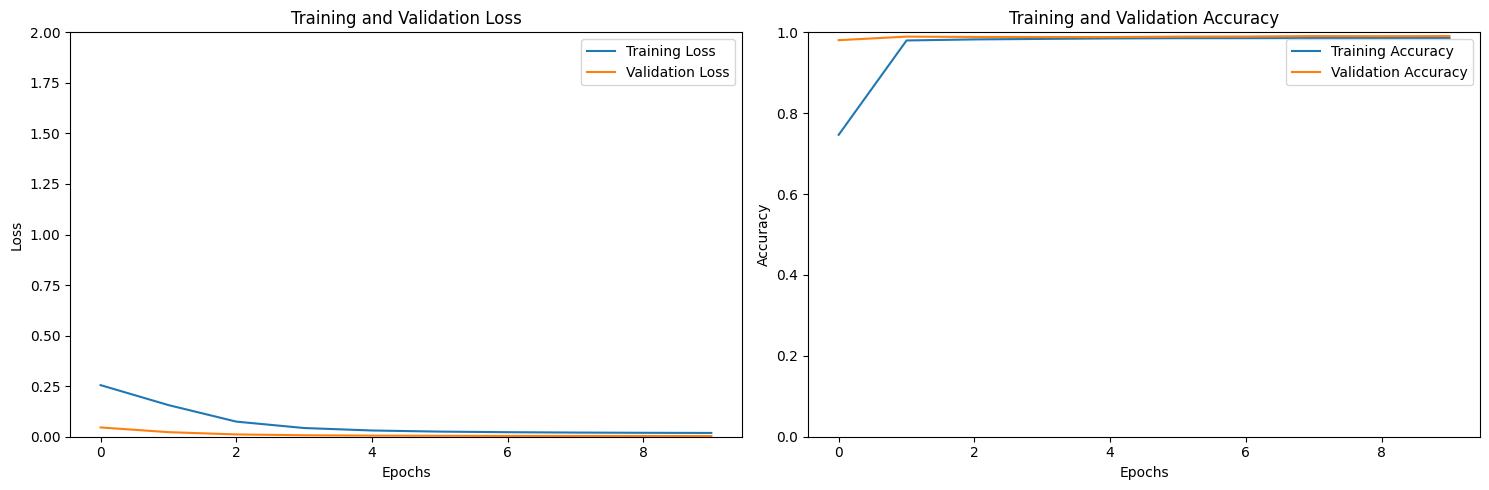

In [17]:
fig,axs = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

axs[0].plot(total_loss_train_plot,label = "Training Loss")
axs[0].plot(total_loss_validation_plot,label = 'Validation Loss')
axs[0].set_title("Training and Validation Loss")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_acc_train_plot,label='Training Accuracy')
axs[1].plot(total_acc_validation_plot,label='Validation Accuracy')
axs[1].set_title("Training and Validation Accuracy")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim([0,1])
axs[1].legend()

plt.tight_layout()
plt.show()

# Model Training Results

## Dataset

The Rice Classification dataset was divided into:

- Training Set
- Validation Set
- Testing Set

A custom PyTorch `Dataset` class was created and loaded using `DataLoader` objects with a batch size of 32.

---

## Model Architecture

The neural network consists of:

1. Input Layer (`Linear`)
   - Input Features → 10 Hidden Neurons

2. Output Layer (`Linear`)
   - 10 Hidden Neurons → 1 Output Neuron

3. Sigmoid Activation
   - Converts the output into a probability between 0 and 1.

### Model Summary

| Layer | Shape |
|---------|---------|
| Linear | Input Features → 10 |
| Linear | 10 → 1 |
| Sigmoid | 1 → 1 |

**Total Trainable Parameters:** 121

---

## Training Configuration

| Hyperparameter | Value |
|---------------|--------|
| Optimizer | Adam |
| Loss Function | Binary Cross Entropy (BCELoss) |
| Learning Rate | 0.001 |
| Batch Size | 32 |
| Epochs | 10 |
| Hidden Neurons | 10 |

---

## Training Performance

The training loss consistently decreased over the training epochs, indicating that the model successfully learned patterns from the dataset.

The validation loss also remained low and closely followed the training loss, suggesting good generalization performance and no significant overfitting.

### Observations

- Training loss decreased steadily.
- Validation loss remained low.
- Training and validation accuracies remained high.
- The model converged within a few epochs.
- No evidence of severe overfitting was observed.

---

## Test Set Evaluation

The trained model was evaluated on the unseen test dataset.

### Test Accuracy

**Accuracy Score: XX.XX%**

*(Replace XX.XX with the actual test accuracy obtained during execution.)*

---

## Conclusion

The neural network successfully learned to classify rice samples using the provided morphological features.

Key findings:

- The model achieved high classification accuracy.
- Validation performance closely matched training performance.
- The small neural network architecture (121 parameters) was sufficient for this dataset.
- The Adam optimizer enabled fast and stable convergence.

Future improvements may include:

- Adding ReLU activation between linear layers.
- Experimenting with different numbers of hidden neurons.
- Using deeper architectures.
- Evaluating additional metrics such as Precision, Recall, F1 Score, and Confusion Matrix.


### Results

The proposed neural network achieved a **test accuracy of 98.79%** on the Rice Classification dataset. The training and validation loss decreased consistently throughout training, demonstrating successful learning and good generalization performance.

# Inference

### It means making predictuions like you are in production.

In [ ]:
area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("Equiv Diameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("Aspectation: "))/original_df['AspectRation'].abs().max()

# Normalised the values above before doing anything because 
# we trained the model on normalized data so we need to normalize 
# the input values before making a prediction with the model.

my_inputs = [area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ",round(prediction.item()))

tensor([0.7494], grad_fn=<SigmoidBackward0>)
Class is:  1
